In [1]:
from google.colab import files
uploaded = files.upload()

Saving Titanic_dataset.csv.xlsx to Titanic_dataset.csv.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [3]:
df = pd.read_excel('Titanic_dataset.csv.xlsx')

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('Missing Values:', df.isnull().sum().sum())
df.head()

Shape: (891, 11)
Columns: ['Passenger_id', 'Survived', 'ticket_class', 'passenger_name', 'gender', 'Age', 'siblings_spouse', 'parents_children', 'ticket_number', 'Fare_price', 'boarding_point']
Missing Values: 0


,Passenger_id,Survived,ticket_class,passenger_name,gender,Age,siblings_spouse,parents_children,ticket_number,Fare_price,boarding_point
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


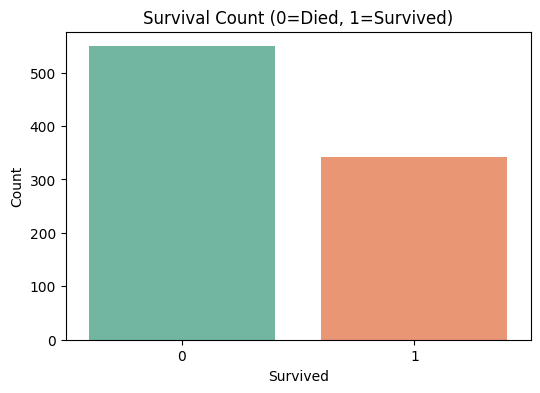

In [4]:
# CELL 3 - Chart 1: Survival Count
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')
plt.title('Survival Count (0=Died, 1=Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

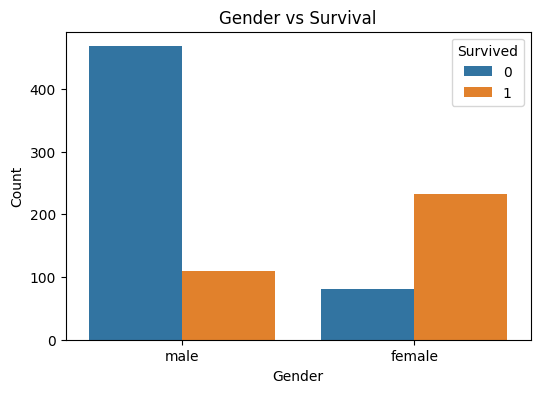

In [5]:
# CELL 4 - Chart 2: Gender vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='gender', hue='Survived', data=df)
plt.title('Gender vs Survival')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

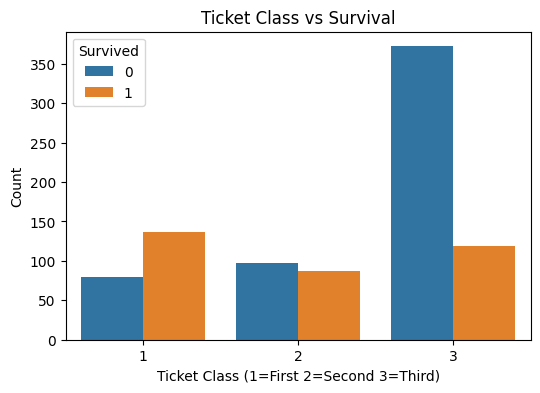

In [6]:
# CELL 5 - Chart 3: Ticket Class vs Survival
plt.figure(figsize=(6,4))
sns.countplot(x='ticket_class', hue='Survived', data=df)
plt.title('Ticket Class vs Survival')
plt.xlabel('Ticket Class (1=First 2=Second 3=Third)')
plt.ylabel('Count')
plt.show()

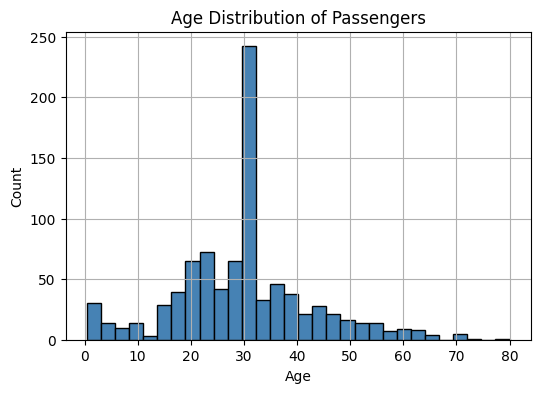

In [7]:
# CELL 6 - Chart 4: Age Distribution
plt.figure(figsize=(6,4))
df['Age'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

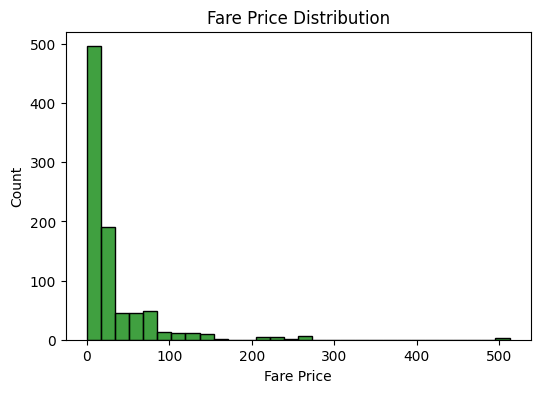

In [8]:
# CELL 7 - Chart 5: Fare Price Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare_price'], color='green', bins=30)
plt.title('Fare Price Distribution')
plt.xlabel('Fare Price')
plt.ylabel('Count')
plt.show()

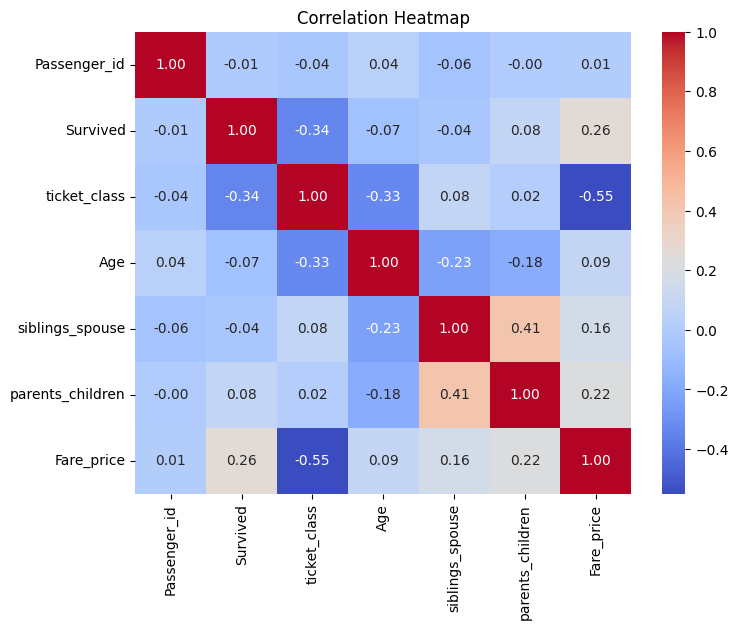

In [9]:
# CELL 8 - Chart 6: Correlation Heatmap
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True,
            cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
# CELL 9 - Build ML Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# STEP A - Convert text columns to numbers
df['gender'] = df['gender'].map({'male': 0, 'female': 1})
df['boarding_point'] = df['boarding_point'].map(
                       {'S': 0, 'C': 1, 'Q': 2})

print('✅ Text converted to numbers!')
print(df[['gender','boarding_point']].head())

✅ Text converted to numbers!
   gender  boarding_point
0       0               0
1       1               1
2       1               0
3       1               0
4       0               0


In [11]:
# CELL 10 - Select Features
# X = Input columns (what model learns FROM)
X = df[['ticket_class', 'gender', 'Age',
        'siblings_spouse', 'parents_children',
        'Fare_price', 'boarding_point']]

# y = Output column (what model PREDICTS)
y = df['Survived']

print('✅ Features selected!')
print('Input shape:', X.shape)
print('Output shape:', y.shape)

✅ Features selected!
Input shape: (891, 7)
Output shape: (891,)


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Convert text to numbers first
df['gender'] = df['gender'].map({'male':0,'female':1})
df['boarding_point'] = df['boarding_point'].map({'S':0,'C':1,'Q':2})

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [14]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc*100:.2f}%')
# You will get around 78-82% ✅

Accuracy: 79.89%
